# UCI Maternal Health Risk: exploratory analysis (P0-10)

**M4 FE-1.** Before Phase 2 trains the risk model, this notebook answers four questions:

1. What is in the dataset, and in which units?
2. How many rows are duplicates, and do any identical readings carry different labels?
3. How balanced are the three risk levels?
4. Which data-quality problems matter for training, for the app's model inputs, and for the open decision on model inputs (P0-11)?

**Data:**
- Source: the [UCI Maternal Health Risk dataset](https://archive.ics.uci.edu/dataset/863/maternal+health+risk), id 863, CC BY 4.0. It is public and de-identified. Cite it in the report.
- It is not stored in this repository. `scripts/download_uci.py` saves it to `ml/data/raw/`, which git ignores.
- MediQore's own testing uses the synthetic generator (LI-10).

**Run:**
1. From `ml/`, run `pip install -r requirements-dev.txt`.
2. Run `python scripts/download_uci.py`.
3. Run all cells.

The tests run this notebook on a small made-up file, so the numbers in the text below refer to the real file (1,014 rows).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from mediqore_ml.uci import (
    FEATURES,
    LABELS,
    TARGET,
    UNITS,
    class_balance,
    conflicting_rows,
    csv_path,
    duplicate_report,
    load_uci,
)

pd.set_option("display.precision", 2)
COLOURS = {"low risk": "#2e7d32", "mid risk": "#f9a825", "high risk": "#c62828"}

df = load_uci()
unique = df.drop_duplicates()
print(f"{csv_path().name}: {len(df)} rows, {len(df.columns)} columns")

maternal_health_risk.csv: 1014 rows, 7 columns


## 1. Columns and units

Six features and one label. MediQore stores one unit per vital (`CLAUDE.md`), and these are the units the model expects:

- **Blood sugar (BS)** is in mmol/L, which is the unit the app stores.
- **Body temperature** is in °F. The app stores °C and converts to °F only at the model input (roadmap Phase 2).
- **HeartRate** is the pulse the visit form collects (M3 FE-1).

In [2]:
pd.DataFrame(
    {
        "unit": pd.Series(UNITS),
        "min": df[FEATURES].min(),
        "median": df[FEATURES].median(),
        "max": df[FEATURES].max(),
        "distinct values": df[FEATURES].nunique(),
    }
)

,unit,min,median,max,distinct values
Age,years,10.0,26.0,70.0,50
SystolicBP,mmHg,70.0,120.0,160.0,19
DiastolicBP,mmHg,49.0,80.0,100.0,16
BS,mmol/L,6.0,7.5,19.0,29
BodyTemp,°F,98.0,98.0,103.0,8
HeartRate,beats/min,7.0,76.0,90.0,16


## 2. Duplicates and conflicting labels

- **Exact duplicates.** If an exact duplicate lands in both the training set and the test set, the test score rises without the model having learnt anything. The roadmap therefore removes duplicates *before* the stratified 20% hold-out split.
- **Conflicting labels.** The same six readings sometimes appear with two different risk levels.

In [3]:
pd.Series(duplicate_report(df), name="count").to_frame()

,count
rows,1014
exact_duplicates,562
unique_rows,452
conflicting_feature_rows,35
unique_rows_in_conflict,71


In [4]:
conflicts = conflicting_rows(unique)
print(f"{len(conflicts)} feature rows carry more than one label:")
conflicts

35 feature rows carry more than one label:


RiskLevel,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,low risk,mid risk,high risk
0,12,90,60,7.5,102.0,66,1,1,0
1,12,95,60,6.9,98.0,65,1,1,0
2,13,90,65,7.5,101.0,80,1,0,1
3,15,120,80,7.5,98.0,70,1,1,0
4,16,100,70,6.9,98.0,80,1,1,0
5,17,85,60,9.0,102.0,86,0,1,1
6,17,90,65,7.5,103.0,67,1,1,0
7,18,90,60,6.9,98.0,70,1,1,0
8,19,120,75,6.9,98.0,66,1,1,0
9,19,120,80,7.0,98.0,70,1,1,0


## 3. Class balance

The balance changes once duplicates are removed: low risk then makes up about half of the rows.

In [5]:
balance = pd.concat({"all rows": class_balance(df), "unique rows": class_balance(unique)}, axis=1)
balance

all rows       unique rows      
              rows share        rows share
RiskLevel                                 
low risk       406  0.40         234  0.52
mid risk       336  0.33         106  0.23
high risk      272  0.27         112  0.25

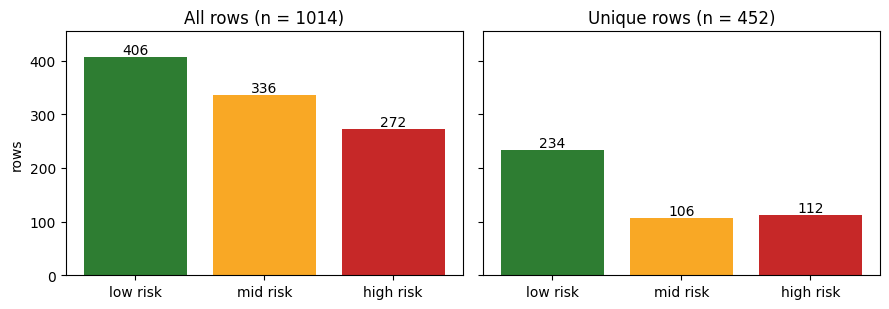

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, (title, data) in zip(axes, [("All rows", df), ("Unique rows", unique)], strict=True):
    counts = class_balance(data)["rows"]
    ax.bar(counts.index, counts.values, color=[COLOURS[label] for label in counts.index])
    ax.set_title(f"{title} (n = {len(data)})")
    ax.margins(y=0.12)
    for i, value in enumerate(counts.values):
        ax.annotate(str(value), (i, value), ha="center", va="bottom")
axes[0].set_ylabel("rows")
fig.tight_layout()

## 4. Features by risk level (unique rows)

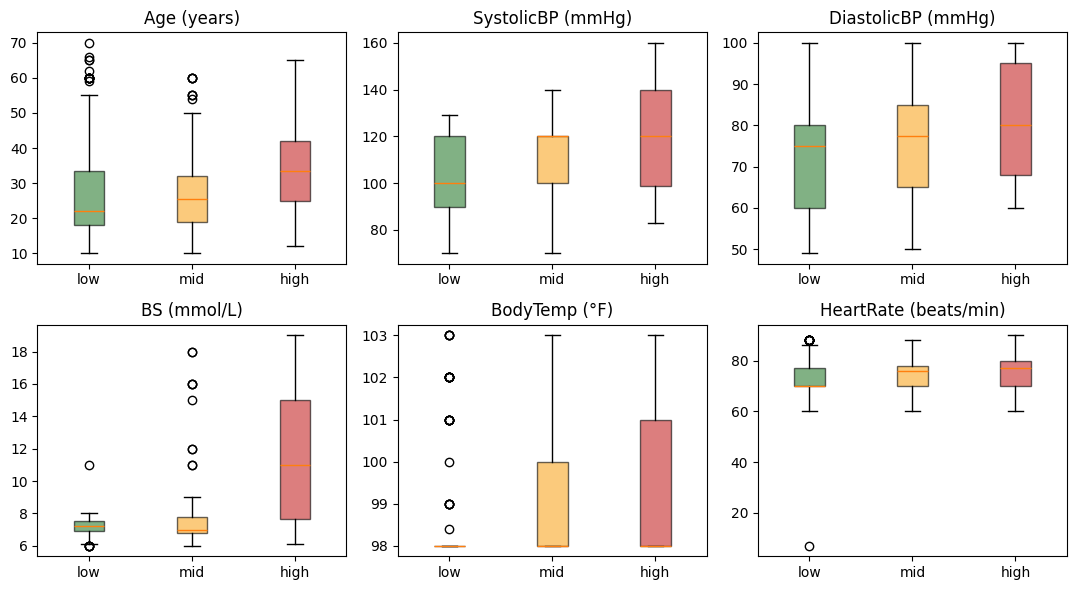

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, feature in zip(axes.flat, FEATURES, strict=True):
    groups = [unique.loc[unique[TARGET] == label, feature] for label in LABELS]
    box = ax.boxplot(groups, patch_artist=True)
    ax.set_xticks(range(1, len(LABELS) + 1), [label.split()[0] for label in LABELS])
    for patch, label in zip(box["boxes"], LABELS, strict=True):
        patch.set_facecolor(COLOURS[label])
        patch.set_alpha(0.6)
    ax.set_title(f"{feature} ({UNITS[feature]})")
fig.tight_layout()

In [8]:
unique.groupby(TARGET)[FEATURES].median().reindex(LABELS)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
low risk,22.0,100.0,75.0,7.2,98.0,70.0
mid risk,25.5,120.0,77.5,7.0,98.0,76.0
high risk,33.5,120.0,80.0,11.0,98.0,77.0


Blood sugar separates the classes most clearly. The next cell counts readings of 8 mmol/L or more in each class. This is a way to describe the data, not a clinical threshold.

In [9]:
high_sugar = (unique["BS"] >= 8).groupby(unique[TARGET]).agg(["sum", "count"]).reindex(LABELS)
high_sugar.columns = ["rows with BS >= 8 mmol/L", "rows"]
high_sugar

,rows with BS >= 8 mmol/L,rows
RiskLevel,,
low risk,3,234
mid risk,19,106
high risk,72,112


## 5. Data quality

In [10]:
checks = {
    "HeartRate below 40 beats/min": lambda d: d["HeartRate"] < 40,
    "Age below 15": lambda d: d["Age"] < 15,
    "Age above 49": lambda d: d["Age"] > 49,
    "BS below 6.0 mmol/L": lambda d: d["BS"] < 6.0,
}
pd.DataFrame(
    {
        "all rows": {name: int(check(df).sum()) for name, check in checks.items()},
        "unique rows": {name: int(check(unique).sum()) for name, check in checks.items()},
    }
)

,all rows,unique rows
HeartRate below 40 beats/min,2,1
Age below 15,54,30
Age above 49,138,60
BS below 6.0 mmol/L,0,0


In [11]:
df["BodyTemp"].value_counts().sort_index().rename("rows").to_frame()

,rows
BodyTemp,
98.0,804
98.4,2
98.6,1
99.0,10
100.0,20
101.0,98
102.0,66
103.0,13


## 6. Findings

These numbers are for the real file (1,014 rows, SHA-256 `a1f70257…` as checked by `scripts/download_uci.py`).

1. **Duplicates.**
   - Only 452 of the 1,014 rows are unique; 562 (55%) are exact duplicates.
   - Scores on the raw file would look better than they are (roadmap, Risks).
   - Phase 2 removes duplicates first, then keeps a stratified 20% hold-out set.
2. **Conflicting labels.**
   - 35 feature rows (71 unique rows) carry more than one label: 24 low/mid, 5 low/high, 5 mid/high and 1 with all three.
   - **To decide in Phase 2 cleaning:** keep them, drop them, or keep the higher label. Report the choice.
3. **Class balance.**
   - All rows: 40% low, 33% mid, 27% high.
   - Unique rows: 52% low (234), 23% mid (106), 25% high (112).
   - This supports SMOTE inside each training fold and per-class recall reporting. With only 112 high-risk rows, the 20% hold-out has about 22 high-risk cases, so one miss moves recall by about 4.5 points. Report this honestly against the 90% target (BO-2).
4. **Blood sugar is the strongest signal.**
   - 72 of 112 unique high-risk rows have BS ≥ 8 mmol/L, against 3 of 234 low-risk rows.
   - A model without blood sugar (roadmap, Risks: used when no reading exists) loses that signal. Its high-risk recall must be measured and reported separately in Phase 2. See P0-11, `docs/decisions/0001-model-inputs.md`.
5. **Training range.**
   - BS is never below 6.0 mmol/L, so a normal reading of 4–5.9 mmol/L from the app lies outside everything the model has seen.
   - Age runs from 10 to 70 (30 unique rows below 15, 60 above 49).
   - Body temperature takes only 8 values, and 79% of rows are exactly 98 °F.
   - Phase 2 must decide how to handle app inputs outside these ranges (for example, clip to the training range) and test it.
6. **Entry errors.** HeartRate = 7 beats/min (2 rows, 1 unique) is almost certainly a typo. Drop it in Phase 2 cleaning.
7. **Units match the plan.** BS in mmol/L is the app's unit; body temperature needs °C → °F at the model input.